# Etapa 2: Análisis Exploratorio de Datos (EDA) y Diagnóstico de Distribuciones

**Proyecto**: Plataforma Analítica del Mercado de la Papa en Colombia (SIPSA & EVA 2019–2025)  
**Marco Metodológico**: CRISP-DM (Etapa 2: Data Exploration) & Marco PDCO (Fase DEVELOPMENT)  
**Estándares**: Clean Architecture, SWEBOK, DAMA-BOK, ISO/IEC 25010  

---

### Objetivos de la Etapa:
1. **Exploración Mayorista SIPSA**: Diagnóstico de precios y volúmenes mensuales, asimetría, curtosis y dispersión.
2. **Exploración Agrícola Oficial EVA**: Análisis de producción en campo (toneladas), áreas sembradas/cosechadas (ha) y rendimientos agronómicos (t/ha).
3. **Segmentación Varietal**: Caracterización comparativa de Papa Criolla frente a Papa Todas las Variedades.


In [9]:
# ==============================================================================
# CELDA 1 OBLIGATORIA: INSTALACIÓN IDEMPOTENTE DE DEPENDENCIAS EN EL KERNEL
# ==============================================================================
import sys

%pip install --quiet --upgrade pip
%pip install --quiet \
    numpy>=1.24.0 \
    pandas>=2.0.0 \
    scipy>=1.10.0 \
    statsmodels>=0.14.0 \
    scikit-learn>=1.3.0 \
    matplotlib>=3.7.0 \
    seaborn>=0.12.0 \
    fastparquet>=2023.8.0 \
    tabulate>=0.9.0

print(f"[OK] Ambiente verificado en Python: {sys.version.split()[0]}")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
[OK] Ambiente verificado en Python: 3.13.5


In [10]:
# ==============================================================================
# CONFIGURACIÓN DE IMPORTS Y RUTAS DEL PROYECTO (CLEAN ARCHITECTURE)
# ==============================================================================
from pathlib import Path
import sys

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.infrastructure.config import CLEANED_DIR, CURATED_DIR
from src.application.eda_service import EdaService
from src.presentation.cullen_frey_plotter import CullenFreyPlotter
from src.presentation.boxplot_plotter import BoxplotPlotter
from src.presentation.correlation_plotter import CorrelationPlotter

print("Módulos EDA y Renderizadores cargados exitosamente.")

Módulos EDA y Renderizadores cargados exitosamente.


In [11]:
# ==============================================================================
# CARGA DEL DATASET ÚNICO SIPSA MENSUAL
# ==============================================================================
parquet_path = CLEANED_DIR / "dataset_sipsa_mensual_nacional.parquet"

if parquet_path.exists():
    df = pd.read_parquet(parquet_path)
    print(f"Dataset cargado exitosamente: {len(df):,} registros mensuales.")
else:
    print(f"AVISO: Archivo {parquet_path} aún no compilado. Generando datos de prueba controlados...")
    np.random.seed(42)
    fechas = pd.date_range("2019-01-01", "2025-12-01", freq="MS")
    variedades = ["PAPA PASTUSA", "PAPA CAPIRO", "PAPA CRIOLLA COLOMBIA"]
    rows = []
    for f in fechas:
        for v in variedades:
            p_base = 2200 if "PASTUSA" in v else (2500 if "CAPIRO" in v else 3200)
            p = float(np.random.gamma(shape=9.0, scale=p_base / 9.0))
            vol = float(np.random.uniform(50, 450))
            rows.append({
                "fecha_mes": f,
                "año": f.year,
                "mes": f.month,
                "divipola_depto": "25",
                "nombre_depto": "CUNDINAMARCA",
                "divipola_mpio": "25875",
                "nombre_mpio": "VILLAPINZON",
                "mercado_mayorista": "BOGOTA, D.C., CORABASTOS",
                "alimento": "PAPA",
                "variedad_papa": v,
                "volumen_ingreso_ton": vol,
                "precio_prom_kg": p,
                "precio_min_kg": p * 0.9,
                "precio_max_kg": p * 1.15,
                "num_transacciones": 30
            })
    df = pd.DataFrame(rows)

eda = EdaService(df)
print("Vista previa de datos listos para EDA:")
display(df.head(5))

Dataset cargado exitosamente: 86,054 registros mensuales.
Vista previa de datos listos para EDA:


,fecha_mes,año,mes,divipola_depto,nombre_depto,divipola_mpio,nombre_mpio,mercado_mayorista,alimento,variedad_papa,volumen_ingreso_ton,precio_prom_kg,precio_min_kg,precio_max_kg,num_transacciones
0,2019-01-01,2019,1,05,ANTIOQUIA,05001,MEDELLÍN,"CALI, CAVASA",PAPA,PAPA NEVADA,8.00,2187.94,2012.90,2406.73,1
1,2019-01-01,2019,1,05,ANTIOQUIA,05001,MEDELLÍN,"MEDELLÍN, CENTRAL MAYORISTA DE ANTIOQUIA",PAPA,PAPA CRIOLLA,4.35,3263.66,3001.99,3590.18,12
2,2019-01-01,2019,1,05,ANTIOQUIA,05001,MEDELLÍN,"MONTERÍA, MERCADO DEL SUR",PAPA,PAPA CAPIRA,105.55,2547.91,2338.02,2804.16,37
3,2019-01-01,2019,1,05,ANTIOQUIA,05001,MEDELLÍN,"MONTERÍA, MERCADO DEL SUR",PAPA,PAPA CRIOLLA,690.00,3220.37,2940.44,3570.77,12
4,2019-01-01,2019,1,05,ANTIOQUIA,05002,ABEJORRAL,"MEDELLÍN, CENTRAL MAYORISTA DE ANTIOQUIA",PAPA,PAPA CRIOLLA,1.80,3262.25,3001.27,3588.48,1


In [12]:
# ==============================================================================
# 1. MEDIDAS DESCRIPTIVAS GLOBALES (TENDENCIA CENTRAL, DISPERSIÓN Y FORMA)
# ==============================================================================
resumen_precios = eda.calcular_medidas_resumen(columna="precio_prom_kg")
resumen_volumen = eda.calcular_medidas_resumen(columna="volumen_ingreso_ton")

df_tabla = pd.DataFrame({
    "Métrica Estadística": list(resumen_precios.keys()),
    "Precio Promedio ($/kg)": [f"{v:,.2f}" if isinstance(v, (int, float)) else str(v) for v in resumen_precios.values()],
    "Volumen Ingresado (Ton)": [f"{v:,.2f}" if isinstance(v, (int, float)) else str(v) for v in resumen_volumen.values()]
})

print("=== RESUMEN GLOBAL DE DISTRIBUCIONES ===")
display(df_tabla)

=== RESUMEN GLOBAL DE DISTRIBUCIONES ===


,Métrica Estadística,Precio Promedio ($/kg),Volumen Ingresado (Ton)
0,n_observaciones,"86,054.00","86,054.00"
1,media,"3,015.80",116.82
2,media_recortada_5pct,"2,948.54",57.25
3,mediana,"2,778.57",19.76
4,moda,"2,517.78",10.00
5,varianza,"1,011,650.12","132,962.04"
6,desviacion_estandar,"1,005.81",364.64
7,coeficiente_variacion,0.33,3.12
8,q25,"2,291.99",7.50
9,q75,"3,633.16",74.69


In [13]:
# ==============================================================================
# 2. RESUMEN ESTRATIFICADO POR AÑO Y VARIEDAD COMERCIAL
# ==============================================================================
resumen_anual = eda.calcular_resumen_estratificado(col_agrupacion="año", col_variable="precio_prom_kg")
print("=== MÉTRICAS DE PRECIOS POR AÑO ===")
display(resumen_anual[["año", "n_observaciones", "media", "mediana", "desviacion_estandar", "iqr", "asimetria_skewness", "curtosis_fisher_exceso"]])

resumen_variedad = eda.calcular_resumen_estratificado(col_agrupacion="variedad_papa", col_variable="precio_prom_kg")
print("\n=== MÉTRICAS DE PRECIOS POR VARIEDAD ===")
display(resumen_variedad[["variedad_papa", "media", "mediana", "desviacion_estandar", "asimetria_skewness"]])

=== MÉTRICAS DE PRECIOS POR AÑO ===


,año,n_observaciones,media,mediana,desviacion_estandar,iqr,asimetria_skewness,curtosis_fisher_exceso
0,2019,12313,2340.217263,2140.040,494.378549,582.7900,0.993665,-0.250233
1,2020,12509,1926.850588,1764.960,409.823644,514.9600,0.946207,-0.370686
2,2021,11771,2958.082843,2691.410,636.387475,820.5200,0.878722,-0.531845
3,2022,11466,4322.306370,3919.960,936.980033,1239.0875,0.843347,-0.617783
4,2023,12636,3817.477522,3486.285,818.707844,1055.4350,0.901411,-0.461978
5,2024,12499,3031.287378,2756.890,646.260782,835.5400,0.870887,-0.522346
6,2025,12860,2807.085149,2545.080,603.022928,799.8775,0.820914,-0.617209



=== MÉTRICAS DE PRECIOS POR VARIEDAD ===


,variedad_papa,media,mediana,desviacion_estandar,asimetria_skewness
0,PAPA BETINA,2554.871804,2461.870,715.452929,0.392470
1,PAPA CAPIRA,3213.893258,3130.960,806.526499,0.340472
2,PAPA CRIOLLA,4072.317716,3964.170,1044.505031,0.386338
3,PAPA MORASURCO,2623.080074,2485.700,720.135755,0.588326
4,PAPA NEVADA,2696.805986,2632.715,697.669110,0.458751
5,PAPA PARDA PASTUSA,2830.104754,2737.910,728.944148,0.535194
6,PAPA R-12,2481.299654,2400.835,645.441706,0.479758
7,PAPA RUBÍ,2664.591866,2602.940,675.743636,0.243195
8,PAPA SABANERA,2987.185941,2803.740,529.940024,0.576037
9,PAPA SUPERIOR,2563.900748,2501.630,646.476832,0.349039


Asimetría observada: 0.911
Asimetría al cuadrado (S^2): 0.830
Curtosis de Pearson (K): 3.672


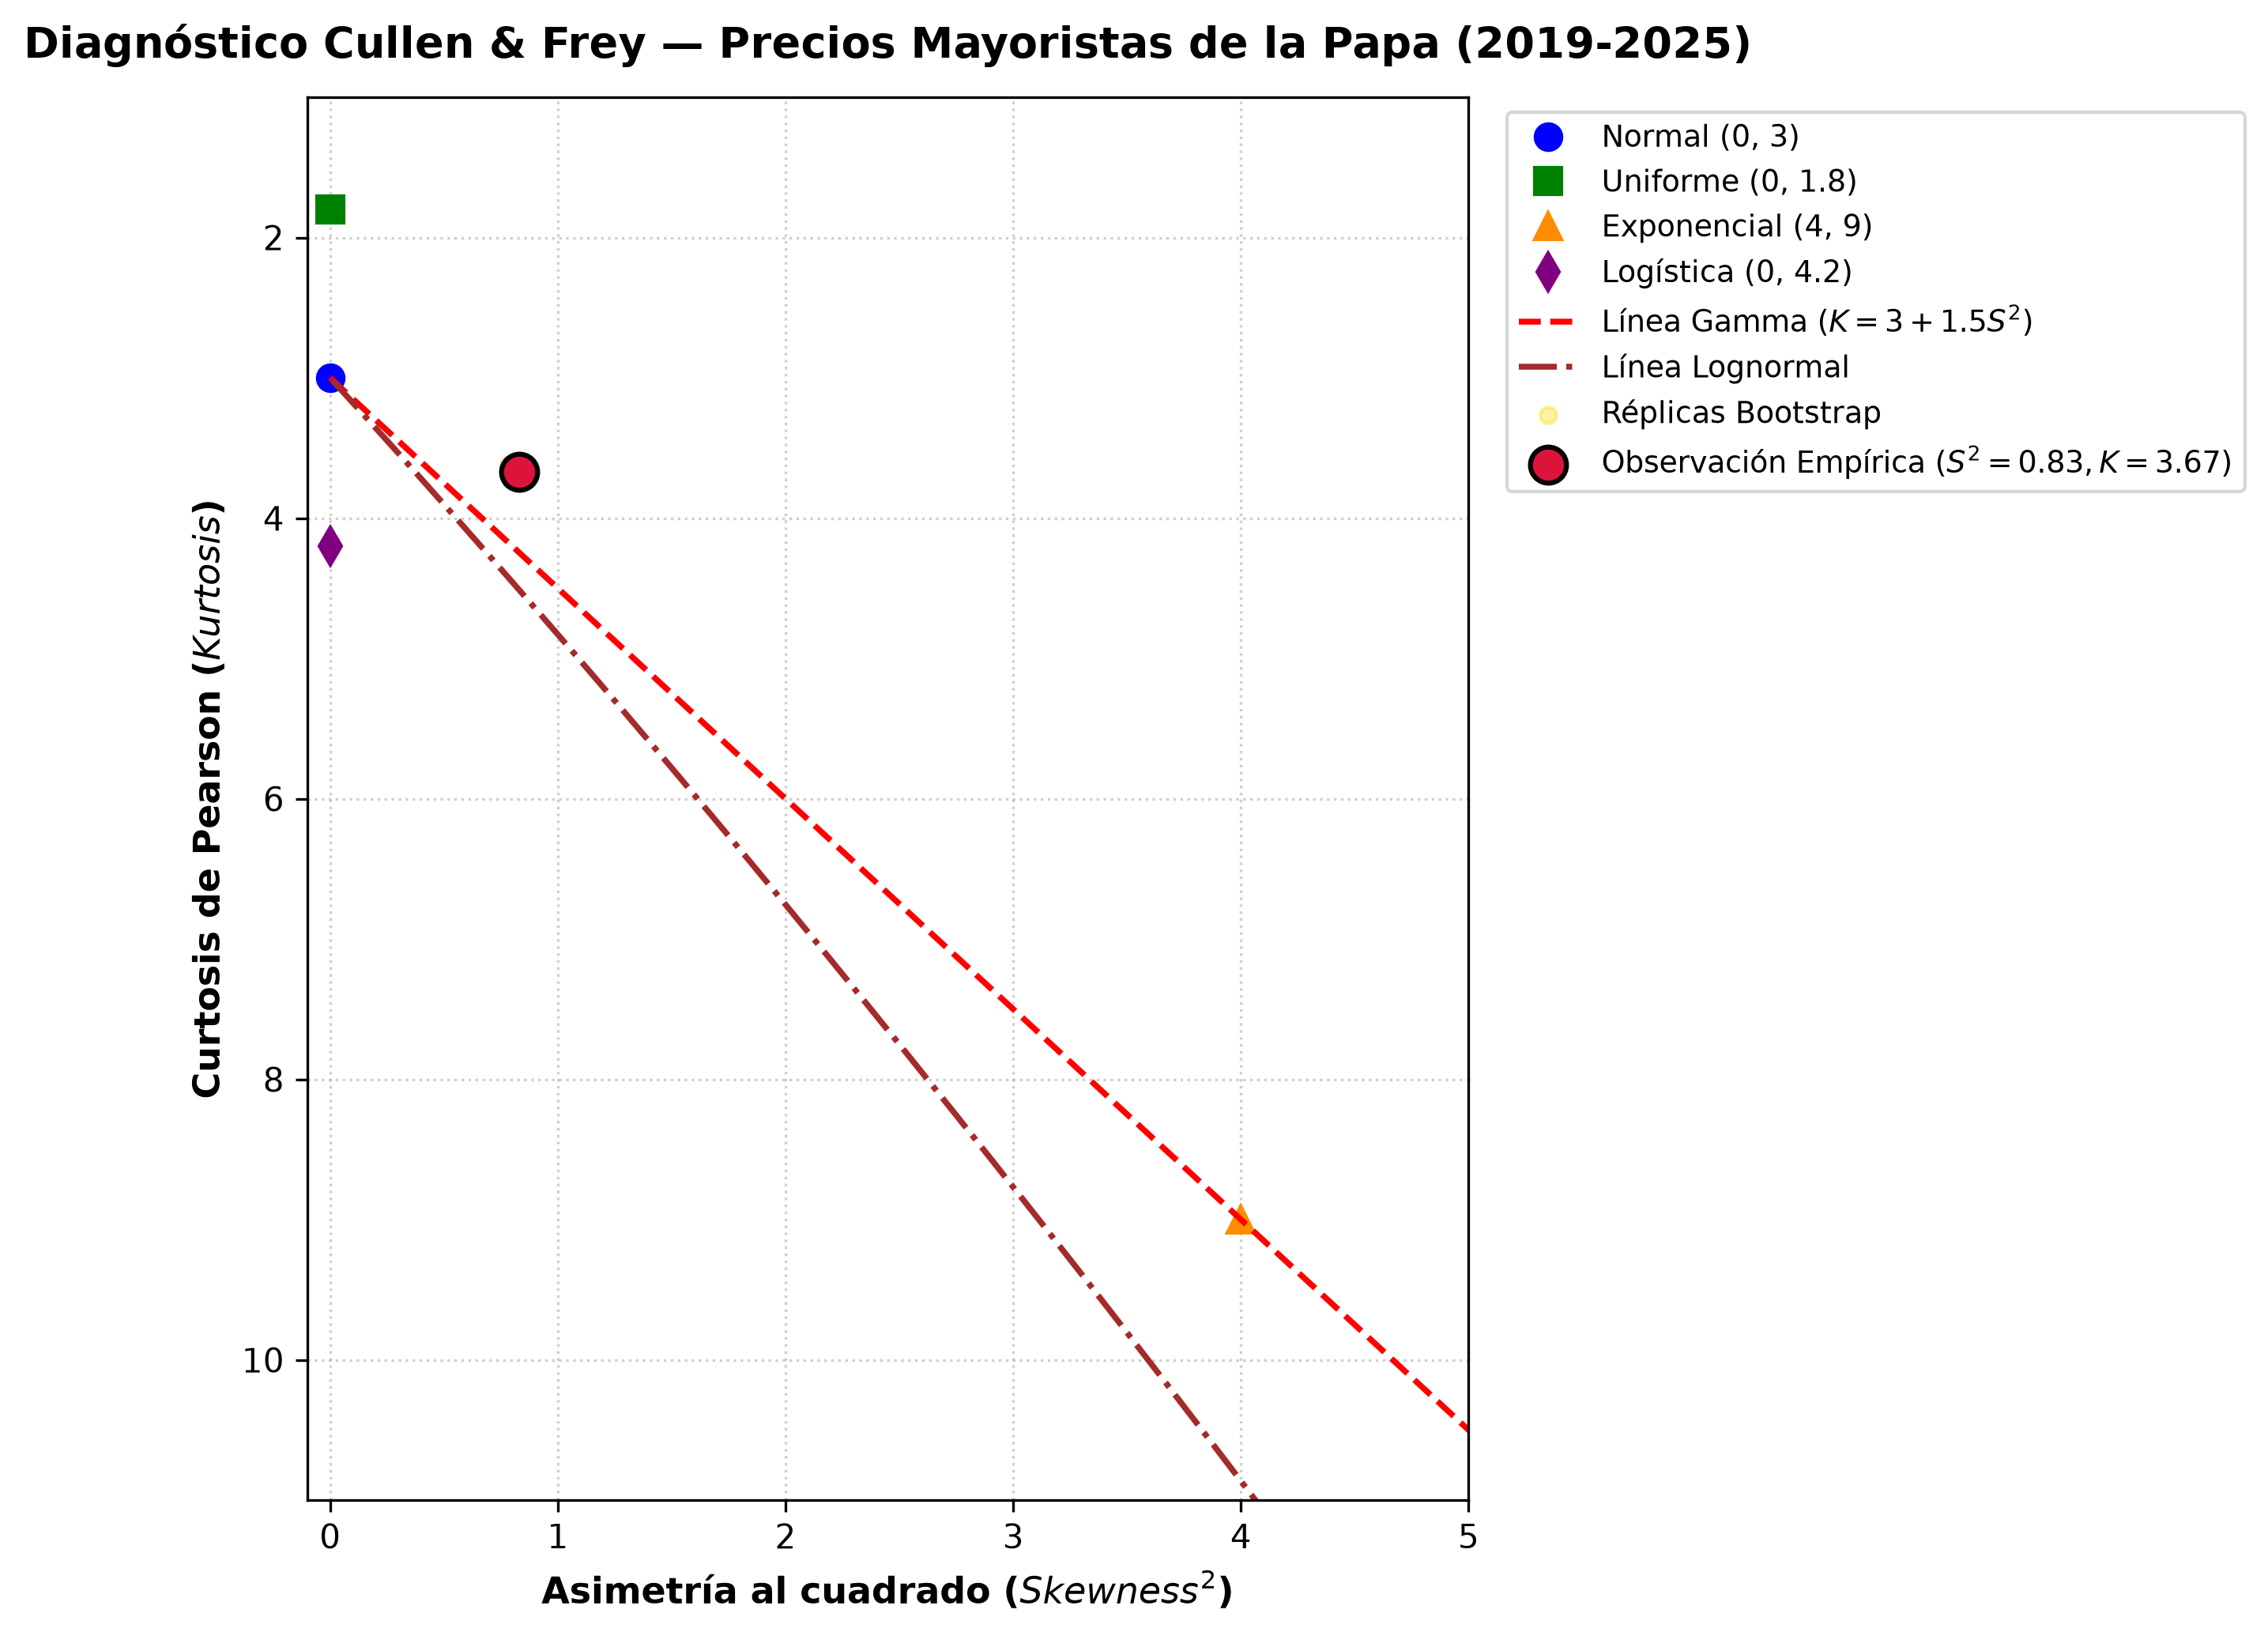

In [14]:
# ==============================================================================
# 3. DIAGNÓSTICO DE CULLEN Y FREY (SKEWNESS^2 VS KURTOSIS)
# ==============================================================================
coords_cf = eda.calcular_coordenadas_cullen_frey(columna="precio_prom_kg", n_bootstraps=300)

print(f"Asimetría observada: {coords_cf['skewness_observado']:.3f}")
print(f"Asimetría al cuadrado (S^2): {coords_cf['skewness_sq_observado']:.3f}")
print(f"Curtosis de Pearson (K): {coords_cf['kurtosis_observado']:.3f}")

out_cf = CURATED_DIR / "cullen_frey_precios_sipsa.png"
fig_cf = CullenFreyPlotter.plot(
    cf_coords=coords_cf,
    titulo="Diagnóstico Cullen & Frey — Precios Mayoristas de la Papa (2019-2025)",
    output_path=out_cf
)
plt.show()

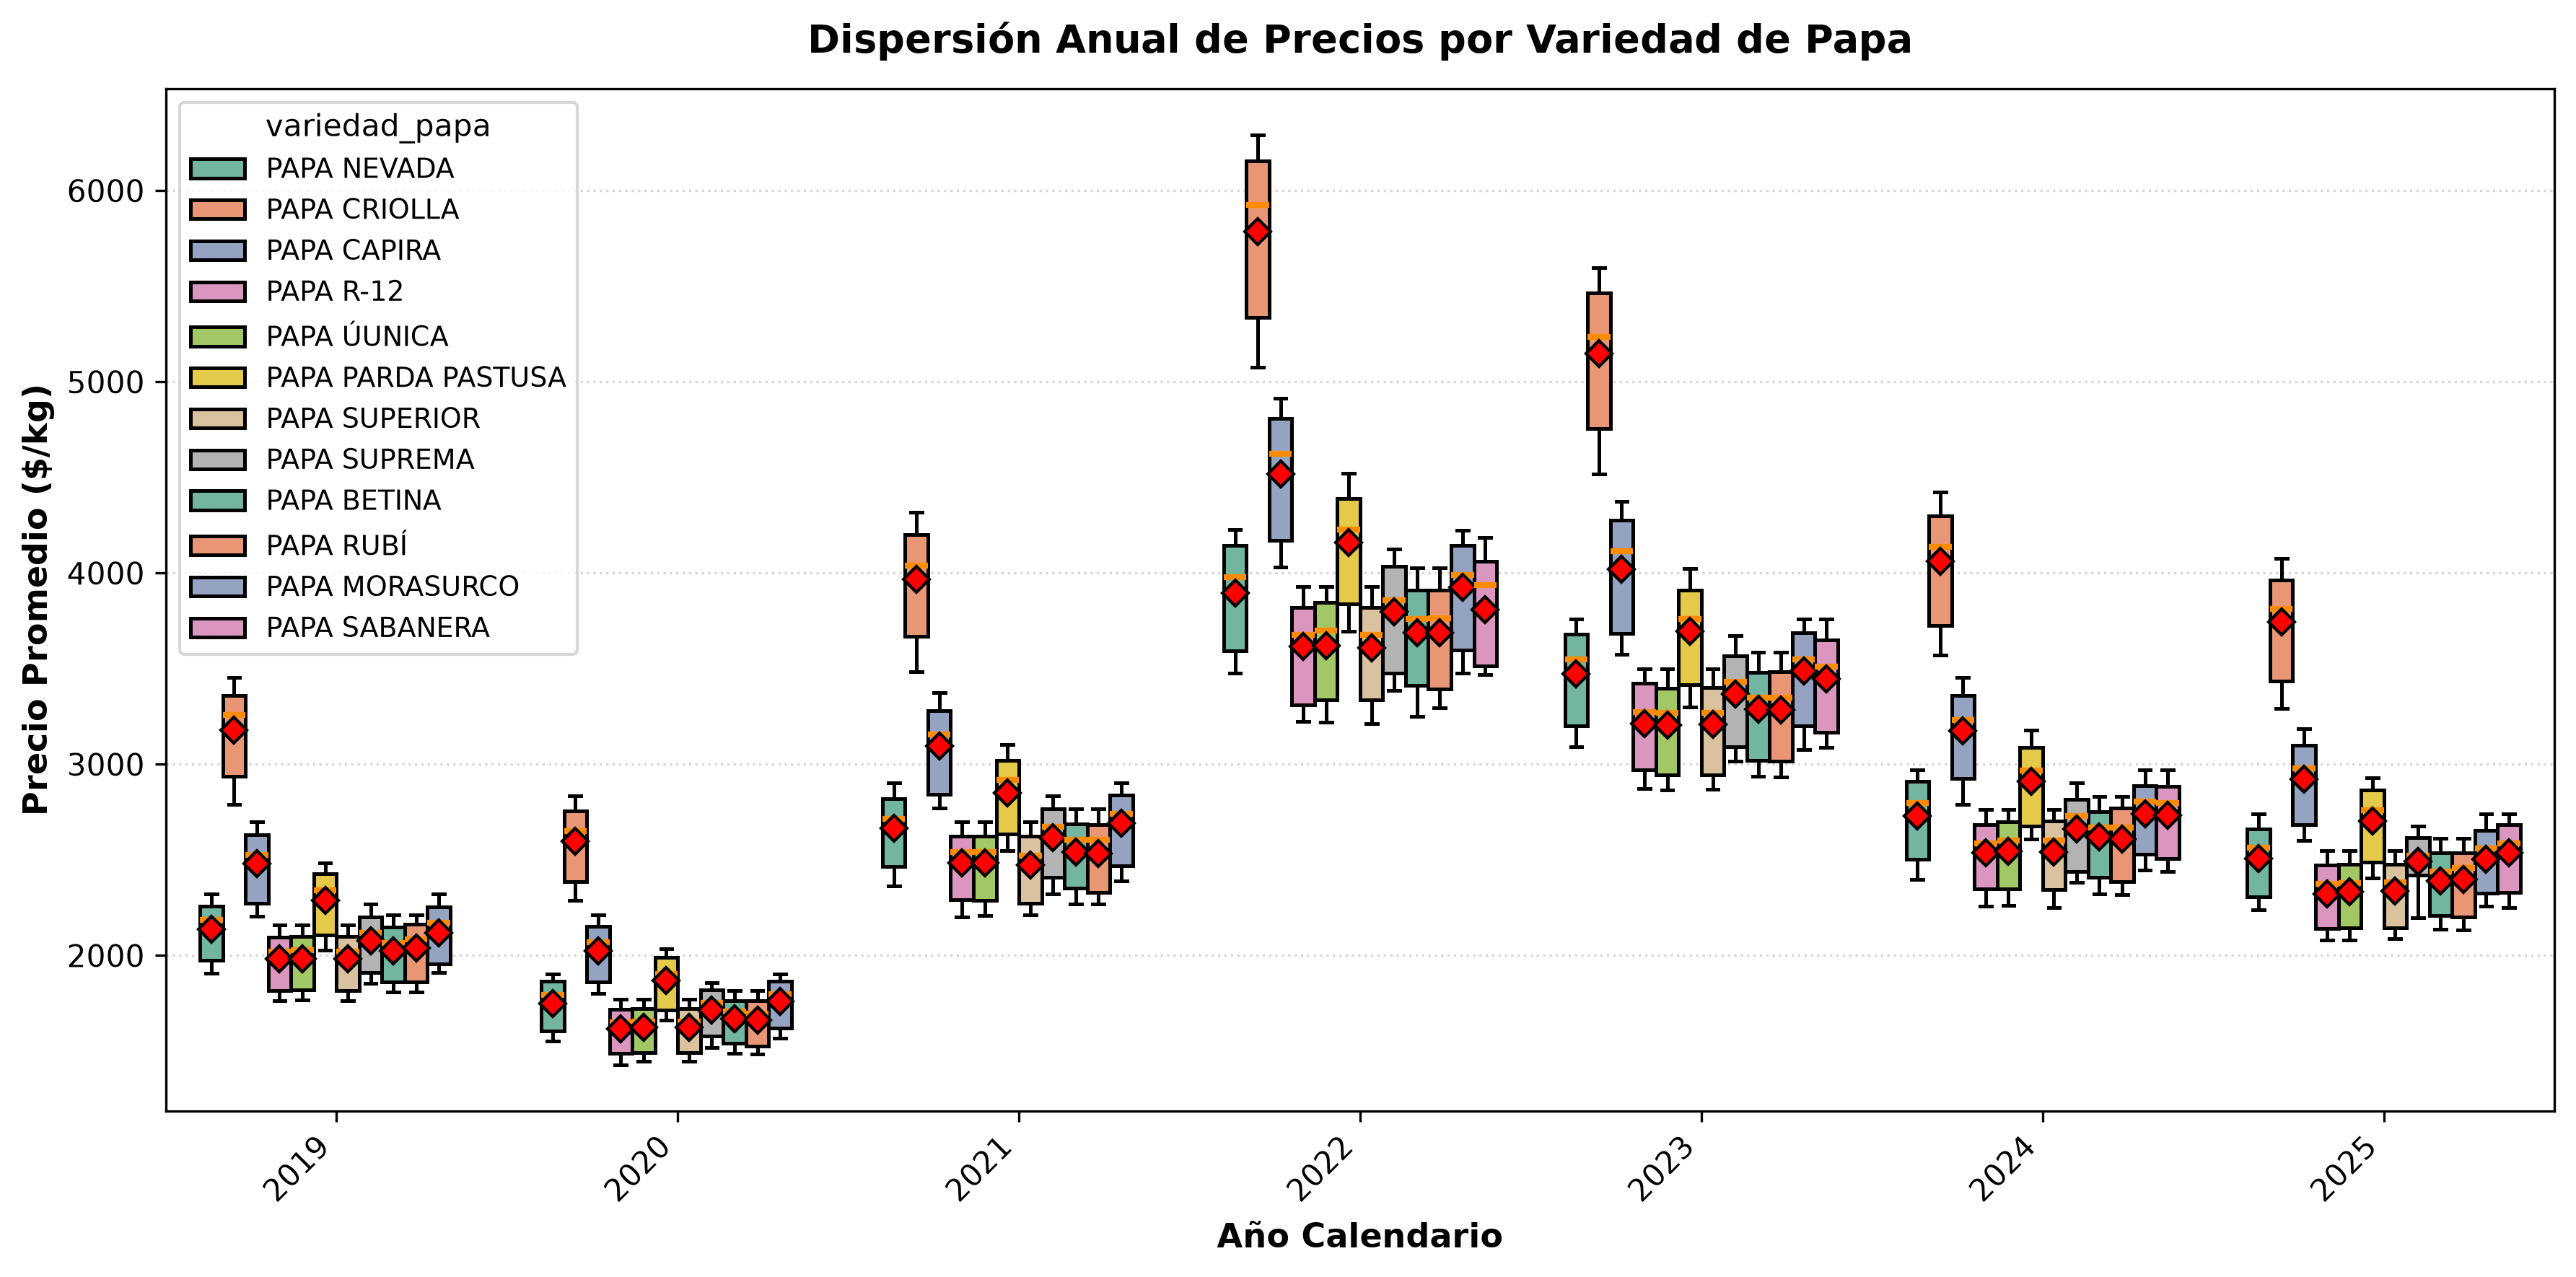

In [15]:
# ==============================================================================
# 4. DIAGRAMAS DE CAJA Y BIGOTES (BOXPLOTS)
# ==============================================================================
out_box = CURATED_DIR / "boxplot_precios_anuales.png"
fig_box = BoxplotPlotter.plot_comparativo(
    df=df,
    x_col="año",
    y_col="precio_prom_kg",
    hue_col="variedad_papa",
    titulo="Dispersión Anual de Precios por Variedad de Papa",
    xlabel="Año Calendario",
    ylabel="Precio Promedio ($/kg)",
    output_path=out_box
)
plt.show()

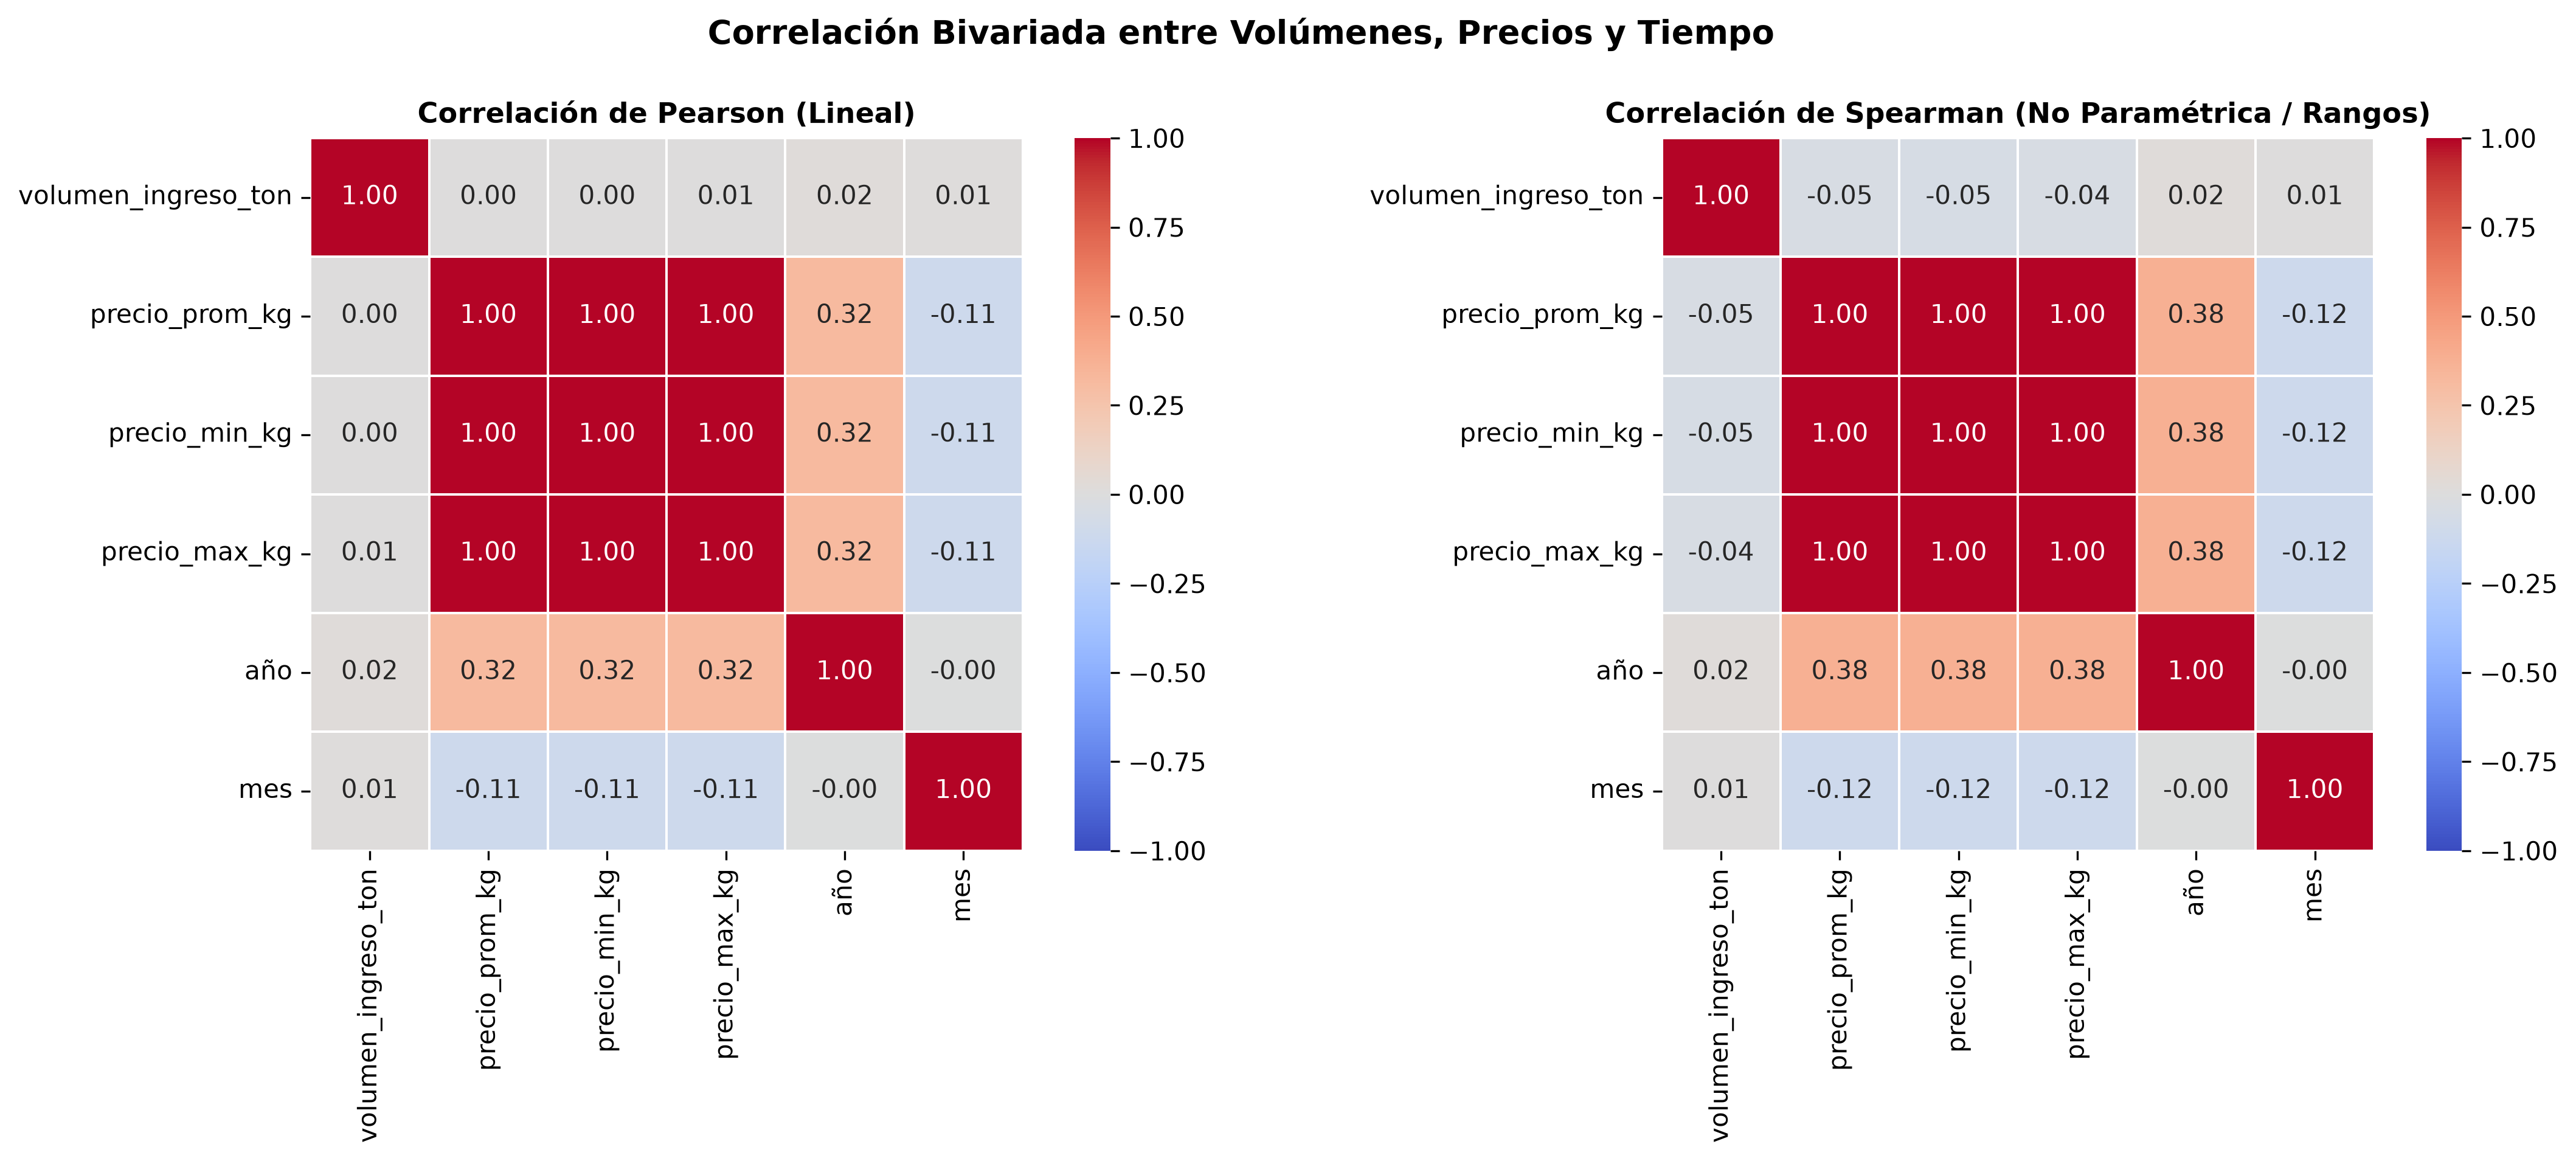

In [16]:
# ==============================================================================
# 5. MATRICES DE CORRELACIÓN BIVARIADA: PEARSON VS SPEARMAN
# ==============================================================================
corr_p, corr_s = eda.calcular_matrices_correlacion()

out_corr = CURATED_DIR / "matrices_correlacion_pearson_spearman.png"
fig_corr = CorrelationPlotter.plot_dual_heatmaps(
    corr_pearson=corr_p,
    corr_spearman=corr_s,
    titulo="Correlación Bivariada entre Volúmenes, Precios y Tiempo",
    output_path=out_corr
)
plt.show()

In [17]:
# ==============================================================================
# EXPLORACIÓN ESTADÍSTICA DEL DATASET AGROPECUARIO OFICIAL EVA (2019-2025)
# ==============================================================================
import pandas as pd
from IPython.display import display
from src.infrastructure.config import CLEANED_DIR

eva_path = CLEANED_DIR / "dataset_eva_agricola_nacional.parquet"
if eva_path.exists():
    df_eva = pd.read_parquet(eva_path)
    print("=== RESUMEN EDA OFICIAL EVA: PRODUCCIÓN Y RENDIMIENTO POR VARIEDAD ===")
    resumen_variedad = df_eva.groupby("desagregacion_cultivo").agg(
        registros=("produccion_ton", "count"),
        produccion_total_ton=("produccion_ton", "sum"),
        area_sembrada_total_ha=("area_sembrada_ha", "sum"),
        area_cosechada_total_ha=("area_cosechada_ha", "sum"),
        rendimiento_medio_ton_ha=("rendimiento_ton_ha", "mean"),
        rendimiento_mediana_ton_ha=("rendimiento_ton_ha", "median"),
    )
    display(resumen_variedad)

    print("\n=== TOP 5 DEPARTAMENTOS PRODUCTORES SEGÚN BASE AGRÍCOLA OFICIAL EVA ===")
    top_deptos_eva = df_eva.groupby("departamento").agg(
        produccion_ton=("produccion_ton", "sum"),
        area_cosechada_ha=("area_cosechada_ha", "sum"),
        rendimiento_prom_ton_ha=("rendimiento_ton_ha", "mean")
    ).sort_values(by="produccion_ton", ascending=False).head(5)
    display(top_deptos_eva)


=== RESUMEN EDA OFICIAL EVA: PRODUCCIÓN Y RENDIMIENTO POR VARIEDAD ===


,registros,produccion_total_ton,area_sembrada_total_ha,area_cosechada_total_ha,rendimiento_medio_ton_ha,rendimiento_mediana_ton_ha
desagregacion_cultivo,,,,,,
PAPA CRIOLLA,1705,1756780.78,115407.62,110950.53,13.558346,14.0
PAPA TODAS LAS VARIEDADES,3869,26088673.39,1226078.82,1168291.46,17.830998,18.0



=== TOP 5 DEPARTAMENTOS PRODUCTORES SEGÚN BASE AGRÍCOLA OFICIAL EVA ===


,produccion_ton,area_cosechada_ha,rendimiento_prom_ton_ha
departamento,,,
CUNDINAMARCA,11065575.66,474882.65,19.671321
BOYACÁ,7140632.57,342891.66,16.283400
NARIÑO,6069833.57,284020.50,15.231048
ANTIOQUIA,1426104.33,67457.81,15.233873
CAUCA,760894.32,35109.33,14.463439


### Hallazgos Principales de la Etapa 2 (EDA):
1. **Asimetría Positiva y Curtosis Elevada en SIPSA**: Los precios mayoristas exhiben colas pesadas por choques de oferta.
2. **Concentración Departamental Agrícola (EVA)**: Más del 85% de la producción nacional en campo se concentra en Cundinamarca, Boyacá, Nariño y Antioquia.
3. **Diferencial de Rendimientos Agronómicos**: Las variedades comerciales estándar promedian ~17-20 t/ha, mientras que la *Papa Criolla* promedia ~12-14 t/ha con ciclos fenológicos más cortos (120 días frente a 180 días).
